In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

df_pangeo = pd.read_csv('Documents/Masters Thesis CSV/ssp245_pangeo_generation.csv')
print("Columns in ssp245_pangeo_generation.csv:", df_pangeo.columns.tolist())

Columns in ssp245_pangeo_generation.csv: ['Unnamed: 0', 'source_id', 'experiment_id', 'year', 'tas']


In [2]:
# List unique values in the 'source_id' column
unique_source_ids = df_pangeo['source_id'].unique()
print("Unique source_ids in df_pangeo:")
print(unique_source_ids)

Unique source_ids in df_pangeo:
['ACCESS-CM2' 'AWI-CM-1-1-MR' 'BCC-CSM2-MR' 'CAMS-CSM1-0' 'CAS-ESM2-0'
 'CESM2-WACCM' 'CIESM' 'CMCC-CM2-SR5' 'CMCC-ESM2' 'CanESM5' 'E3SM-1-1'
 'EC-Earth3' 'EC-Earth3-CC' 'EC-Earth3-Veg' 'EC-Earth3-Veg-LR'
 'FGOALS-f3-L' 'FGOALS-g3' 'FIO-ESM-2-0' 'GFDL-CM4' 'GFDL-ESM4' 'IITM-ESM'
 'INM-CM4-8' 'INM-CM5-0' 'IPSL-CM6A-LR' 'KACE-1-0-G' 'KIOST-ESM' 'MIROC6'
 'MPI-ESM1-2-HR' 'MPI-ESM1-2-LR' 'MRI-ESM2-0' 'NESM3' 'NorESM2-LM'
 'NorESM2-MM' 'TaiESM1']


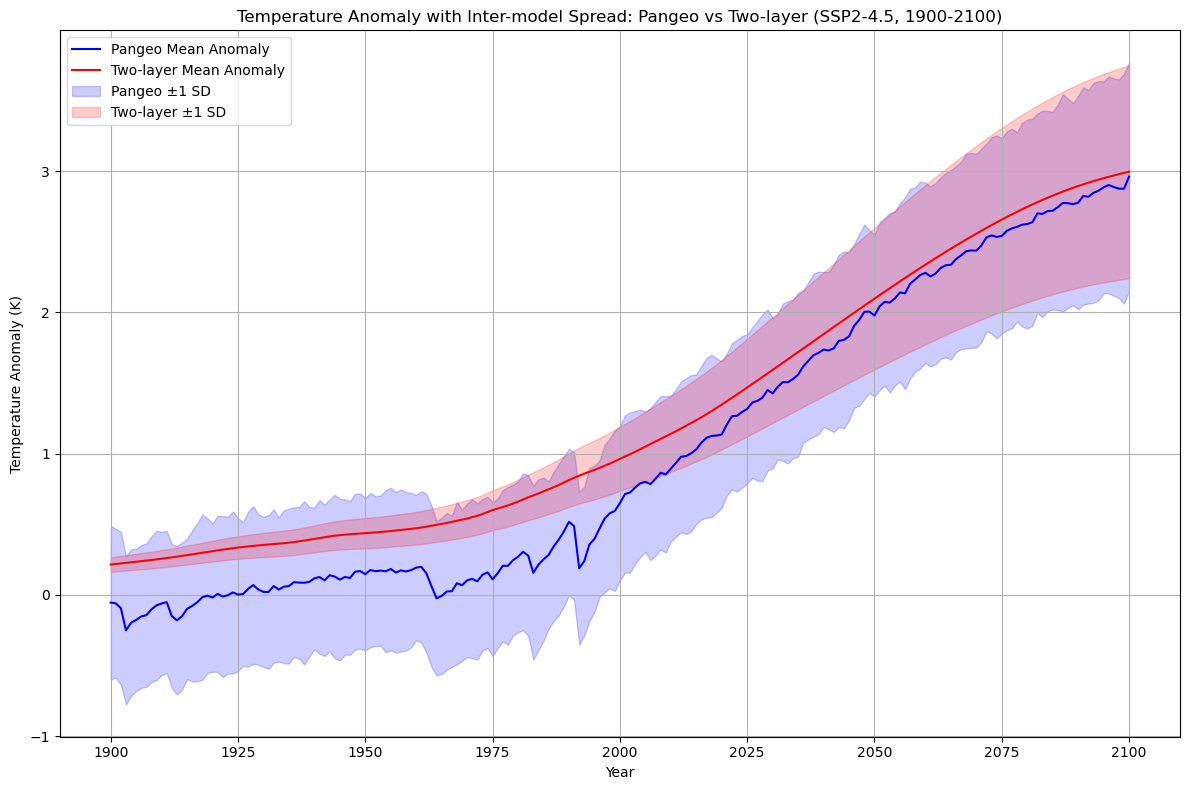

In [3]:
# Load the datasets
df_pangeo = pd.read_csv('Documents/Masters Thesis CSV/ssp245_pangeo_generation.csv')
df_two_layer = pd.read_csv('Documents/Masters Thesis CSV/ssp245_two_layer.csv')

# Compute temperature anomaly for pangeo by subtracting 287 K
df_pangeo['tas_anomaly'] = df_pangeo['tas'] - 287

# Filter two-layer data for years 1900 to 2100
df_two_layer_filtered = df_two_layer[(df_two_layer['Year'] >= 1900) & (df_two_layer['Year'] <= 2100)]

# Compute mean and std deviation for each year for pangeo
pangeo_stats = df_pangeo.groupby('year')['tas_anomaly'].agg(['mean', 'std']).reset_index()
pangeo_stats.columns = ['year', 'mean_anomaly', 'std_anomaly']

# Compute mean and std deviation for each year for two-layer
two_layer_stats = df_two_layer_filtered.groupby('Year')['TS'].agg(['mean', 'std']).reset_index()
two_layer_stats.columns = ['Year', 'mean_TS', 'std_TS']

# Set up the plot
plt.figure(figsize=(12, 8))

# Plot mean lines
plt.plot(pangeo_stats['year'], pangeo_stats['mean_anomaly'], label='Pangeo Mean Anomaly', color='blue')
plt.plot(two_layer_stats['Year'], two_layer_stats['mean_TS'], label='Two-layer Mean Anomaly', color='red')

# Add shaded regions for ±1 standard deviation
plt.fill_between(pangeo_stats['year'], 
                 pangeo_stats['mean_anomaly'] - pangeo_stats['std_anomaly'], 
                 pangeo_stats['mean_anomaly'] + pangeo_stats['std_anomaly'],
                 color='blue', alpha=0.2, label='Pangeo ±1 SD')

plt.fill_between(two_layer_stats['Year'], 
                 two_layer_stats['mean_TS'] - two_layer_stats['std_TS'], 
                 two_layer_stats['mean_TS'] + two_layer_stats['std_TS'],
                 color='red', alpha=0.2, label='Two-layer ±1 SD')

# Customize the plot
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (K)')
plt.title('Temperature Anomaly with Inter-model Spread: Pangeo vs Two-layer (SSP2-4.5, 1900-2100)')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()

# Save the figure
plt.savefig('ssp245_pangeo_2_layer_compare_with_spread.png')

# Show the plot
plt.show()

In [4]:
# For demonstration, here's how you might have computed them:
# df_pangeo is the pangeo DataFrame with a 'tas' column for temperature
# and we subtract 287 K to get the anomaly.
df_pangeo = pd.read_csv('Documents/Masters Thesis CSV/ssp245_pangeo_generation.csv')
df_pangeo['tas_anomaly'] = df_pangeo['tas'] - 287
pangeo_mean = df_pangeo.groupby('year')['tas_anomaly'].mean().reset_index()

# df_two_layer is the two-layer DataFrame with columns 'Year' and 'TS' (anomaly)
df_two_layer = pd.read_csv('Documents/Masters Thesis CSV/ssp245_two_layer.csv')
# Filter for the period 1900-2100 if not already done:
df_two_layer_filtered = df_two_layer[(df_two_layer['Year'] >= 1900) & (df_two_layer['Year'] <= 2100)]
two_layer_mean = df_two_layer_filtered.groupby('Year')['TS'].mean().reset_index()

# Merge annual means for the period 1900-2100.
# Here we assume pangeo_mean (with 'year' and 'tas_anomaly') and two_layer_mean (with 'Year' and 'TS') have already been computed.
merged_all = pd.merge(pangeo_mean, two_layer_mean.rename(columns={'Year': 'year', 'TS': 'two_layer_mean'}), on='year', how='inner')
merged_all = merged_all.rename(columns={'tas_anomaly': 'pangeo_mean'})

# Define 50-year periods (you can adjust the exact boundaries as needed).
# Here we define: 1900-1950, 1951-2000, 2001-2050, and 2051-2100.
periods = [(1900, 1950), (1951, 2000), (2001, 2050), (2051, 2100)]

# Initialize a list to store table rows.
table_rows = []

# Loop through each period and calculate metrics.
for start_year, end_year in periods:
    period_data = merged_all[(merged_all['year'] >= start_year) & (merged_all['year'] <= end_year)]
    if not period_data.empty:
        rmse_val = np.sqrt(np.mean((period_data['two_layer_mean'] - period_data['pangeo_mean'])**2))
        corr_coef, p_val = pearsonr(period_data['two_layer_mean'], period_data['pangeo_mean'])
        bias = np.mean(period_data['two_layer_mean'] - period_data['pangeo_mean'])
        table_rows.append({
            'Period': f"{start_year}-{end_year}",
            'RMSE': rmse_val,
            'Correlation': corr_coef,
            'p-value': p_val,
            'Bias': bias
        })

# Create a DataFrame from the table rows.
rmse_table = pd.DataFrame(table_rows)

# Display the table.
print(rmse_table)

      Period      RMSE  Correlation       p-value      Bias
0  1900-1950  0.330809     0.928200  1.114089e-22  0.327156
1  1951-2000  0.414763     0.831561  7.545508e-14  0.403982
2  2001-2050  0.178535     0.997780  3.833860e-58  0.168873
3  2051-2100  0.093722     0.997058  3.281366e-55  0.091510
